In [2]:
from os.path import join
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from h5py import File

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
data = {
    "PGC": [12, 14, 16, 35, 55],
    "Vcmb": [6179, 11474, 5354, 28, 4466],
    "sgl": [286.4249, 300.8070, 287.6120, 333.3464, 327.0996],
    "sgb": [11.3510, 15.3909, 11.7030, 20.3429, 19.7763],
    "sgx": [17.129890, 56.656425, 15.862818, 0.234638, 35.285696],
    "sgy": [-58.109124, -95.015642, -49.969626, -0.117772, -22.827690],
    "sgz": [12.161442, 30.452339, 10.859977, 0.097339, 15.110653],
    "ix": [66, 71, 66, 64, 68],
    "iy": [56, 51, 57, 63, 61],
    "iz": [65, 67, 65, 64, 65],
    "d_value": [0.117540, 0.089236, 0.106877, 0.104409, -0.010737],
    "v_value": [240.479706, 297.352051, 244.219208, 210.611496, 224.992859],
}

for key in data:
    data[key] = np.asarray(data[key])

data["r"] = np.sqrt(data["sgx"]**2 + data["sgy"]**2 + data["sgz"]**2)

supergalactic_coords = SkyCoord(
    sgl=data["sgl"] * u.deg, sgb=data["sgb"] * u.deg, frame="supergalactic")
icrs_coords = supergalactic_coords.transform_to("icrs")

data["RA"] = icrs_coords.ra.deg
data["dec"] = icrs_coords.dec.deg


fname = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4_test_points.hdf5"
with File(fname, "w") as f:
    for key in data:
        f[key] = data[key]


In [40]:
from astropy.io import fits
from tqdm import trange

vel = []

for n in trange(1, 101):
    # fname = f"/mnt/extraspace/rstiskalek/catalogs/CF4/CF4gp_23avr24_256-z008_test_100_realizations/CF4gp_23avr24_256-z008_test_{n}_realizations.fits"
    fname = f"/mnt/extraspace/rstiskalek/catalogs/CF4/CF4gp_23avr24_256-z008_test_100_realizations/CF4gp_23avr24_256-z008_test_realization{n}_velocity.fits"
    f = fits.open(fname)
    vx, vy, vz = f[0].data
    vx = np.swapaxes(vx, 0, 2)
    vy = np.swapaxes(vy, 0, 2)
    vz = np.swapaxes(vz, 0, 2)
    vel_ = 52 * np.stack([vx, vy, vz])
    vel.append(vel_)
vel = np.stack(vel, axis=0)

100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


In [41]:
bin_edges = np.linspace(0, 1000, 257) - 500

ix = np.digitize(data["sgx"], bin_edges)
iy = np.digitize(data["sgy"], bin_edges)
iz = np.digitize(data["sgz"], bin_edges)

ix = data["ix"]
iy = data["iy"]
iz = data["iz"]

vx = vel[:, 0, ix, iy, iz]
vy = vel[:, 1, ix, iy, iz]
vz = vel[:, 2, ix, iy, iz]

vmag = np.sqrt(vx**2 + vy**2 + vz**2)

In [42]:
print(2 * data["ix"], ix)
print(2 * data["iy"], iy)
print(2 * data["iz"], iz)

[132 142 132 128 136] [66 71 66 64 68]
[112 102 114 126 122] [56 51 57 63 61]
[130 134 130 128 130] [65 67 65 64 65]


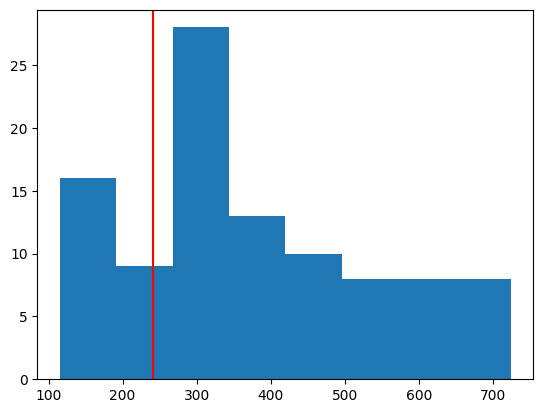

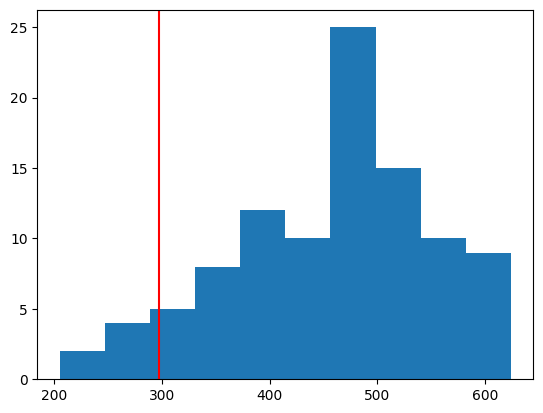

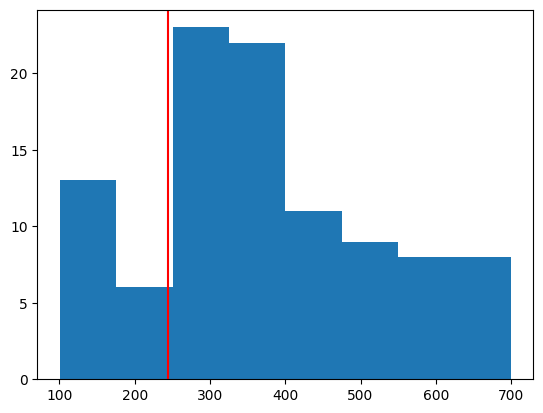

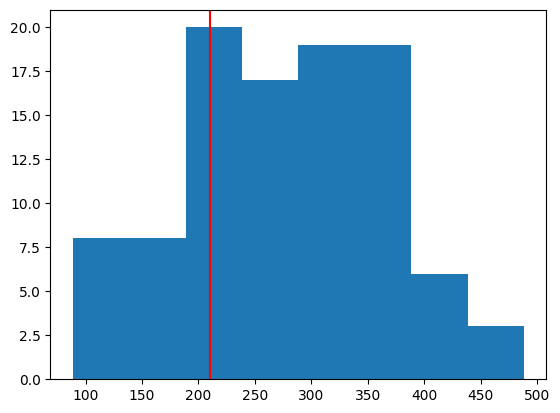

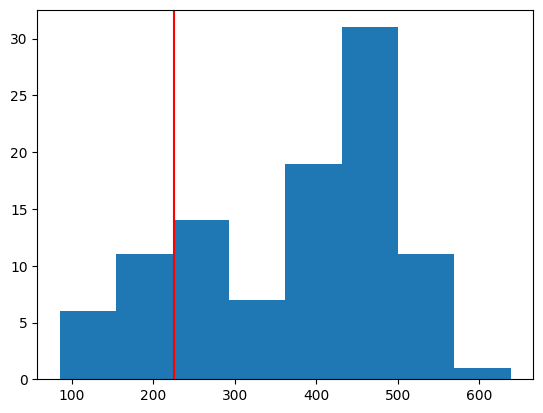

In [43]:
for k in range(5):
    plt.figure()
    plt.hist(vmag[:, k], bins="auto")
    plt.axvline(data["v_value"][k], color="r")
    plt.show()

In [31]:
import csiborgtools

fpath = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4_test_points.hdf5"
paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)

loader = csiborgtools.flow.DataLoader("CF4", [0], "CF4_test_points", fpath, paths, ksmooth=0, )

2025-01-13 23:46:32   reading the catalogue,
2025-01-13 23:46:32   reading the interpolated field.
2025-01-13 23:46:32   calculating the radial velocity.


In [32]:
loader.los_radial_velocity.shape

(1, 5, 800)

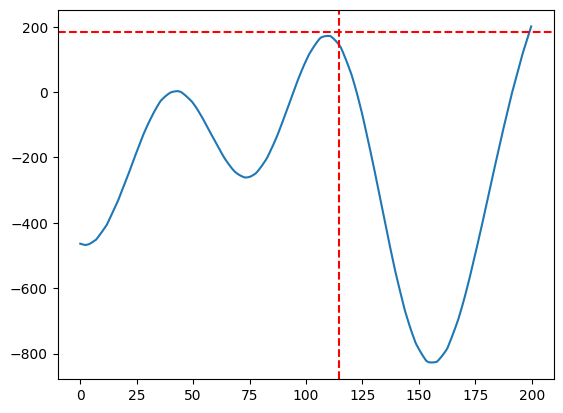

In [30]:
r = [61.78999996, 114.7400003, 53.54000017, 0.28000021, 44.66000008]
Vr = [-91.48706626, 183.7425721, -37.73642425, -487.91701742, 4.50479507]


k = 1

plt.figure()
plt.plot(loader.rdist, loader.los_radial_velocity[0, k])
plt.axvline(r[k], color="r", ls="--")
plt.axhline(Vr[k], color="r", ls="--")
plt.show()




In [3]:





with File("/mnt/extraspace/rstiskalek/csiborg_postprocessing/field_los/los_CF4_test_points_CF4.hdf5", 'r') as f:
    vel = np.stack([f[f"velocity_{n}"][...] for n in range(1, 20 + 1)], axis=0)
    rho = np.stack([f[f"density_{n}"][...] for n in range(1, 20 + 1)], axis=0)
    r = f["rdist_1"][...]

# vel_mag = np.linalg.norm(vel, axis=1)

/tmp/ipykernel_2373513/2157743941.py:28: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


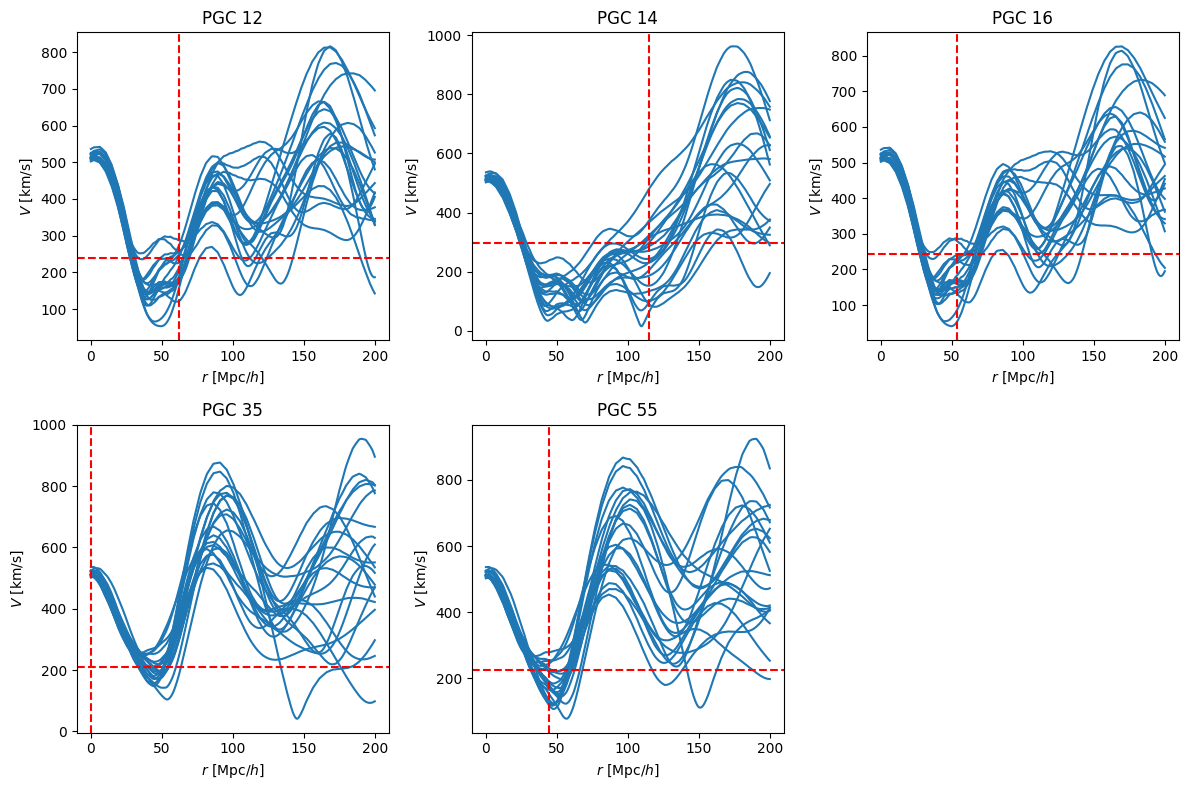

In [4]:
num_panels = 5
num_cols = 3
num_rows = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8), constrained_layout=True)
cols = plt.rcParams['axes.prop_cycle'].by_key()['color']
axes = axes.flatten()

for k in range(num_panels):
    ax = axes[k]
    for n in range(20):
        ax.plot(r, vel_mag[n, k, :, 0], c=cols[0])

    # Add vertical and horizontal lines
    ax.axvline(data["r"][k], c="red", ls='--')
    ax.axhline(data["v_value"][k], c="red", ls='--')

    ax.set_title(f"PGC {data['PGC'][k]}")
    ax.set_xlabel(r"$r ~ [\mathrm{Mpc} / h]$")
    ax.set_ylabel(r"$V ~ [\mathrm{km} / \mathrm{s}]$")

    # ax.set_xlim(0, r.max())

# Hide empty subplots if num_panels < num_rows * num_cols
for ax in axes[num_panels:]:
    ax.axis("off")

fig.tight_layout()
fig.show()

/tmp/ipykernel_2373513/3846585018.py:28: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


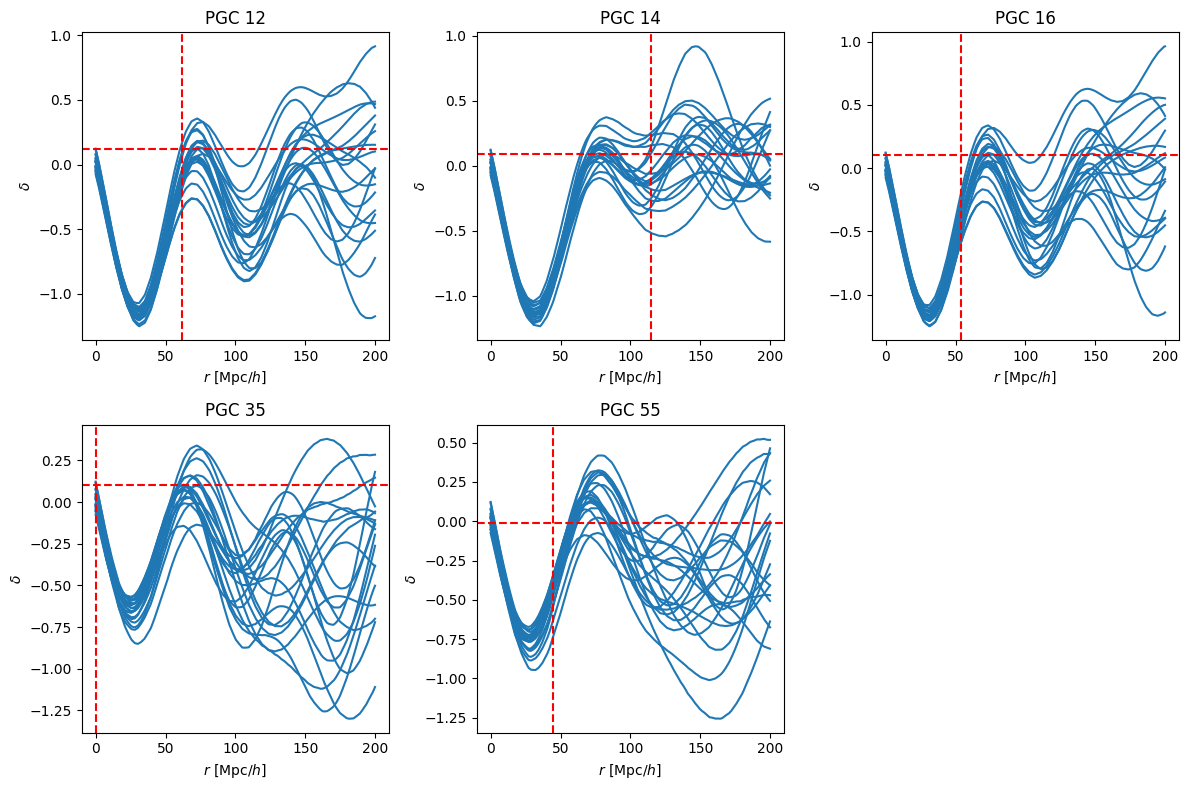

In [5]:
num_panels = 5
num_cols = 3
num_rows = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8), constrained_layout=True)
cols = plt.rcParams['axes.prop_cycle'].by_key()['color']
axes = axes.flatten()

for k in range(num_panels):
    ax = axes[k]
    for n in range(20):
        ax.plot(r, rho[n, k, :, 0], c=cols[0])

    # Add vertical and horizontal lines
    ax.axvline(data["r"][k], c="red", ls='--')
    ax.axhline(data["d_value"][k], c="red", ls='--')

    ax.set_title(f"PGC {data['PGC'][k]}")
    ax.set_xlabel(r"$r ~ [\mathrm{Mpc} / h]$")
    ax.set_ylabel(r"$\delta$")

    # ax.set_xlim(0, r.max())

# Hide empty subplots if num_panels < num_rows * num_cols
for ax in axes[num_panels:]:
    ax.axis("off")

fig.tight_layout()
fig.show()